<a href="https://colab.research.google.com/github/ChenXie-astro/corgietc/blob/main/08_polarization_measurement_RL6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polarization Measurement

This notebook demonstrates setting up integration time calculations in POL mode.


If running via Google Colab, you must first execute the contents of notebook `00_Google_Colab_Setup.ipynb` (only if you have never done so previously). Then execute all cells tagged with &#128992;.  If running via a local installation, you should skip all of the colab-specific (&#128992;) cells.

## 🟠 Setup for Google Colab Use

### 🟠 Run the next cell to mount the Google Drive

You will receive some or all of the following prompts:

* Warning: This notebook was not authored by Google - Click "Run Anyway"
* Permit this notebook to access your Google Drive files? - Click "Connect to Google Drive"
* A new browser window will prompt you to select an account and authorize access
  * Select the Google account you wish to use and click Continue on each subsequent screen until the dialog vanishes

Upon completion of cell execution, you should see `Mounted at /content/drive`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 🟠 Run the next cell to change to the corgietc directory and install the required software

This process should take less than a minute, but, depending on bandwidth availability, may take as long as a few minutes. You will see a variety of messages about package downloads.  Upon completion of cell execution, you should see `Sucessfully installed` followed by a list of installed packages and their versions.

You may see the prompt "Restart session".  You do not need to do this - click 'Cancel'.

In [2]:
# This cell should *only* be executed if running the notebook in Google Colab
import os

# Google top level drive dir
drive_dir = "/content/drive/MyDrive/"

# directory path
corgietc_dir = 'corgietc'
corgietc_path = os.path.join(drive_dir, corgietc_dir)
cgi_noise_repo_path = os.path.join(corgietc_path, "cgi_noise")
corgietc_repo_path = os.path.join(corgietc_path, "corgietc")
corgietc_notebooks_path = os.path.join(corgietc_repo_path, "Notebooks")

# Change to the cgi_noise repo path and update the repo
os.chdir(cgi_noise_repo_path)
!git pull

# Install the backend and all requirements - this can also take a little while
!pip install .

# Change to the corgietc repo path and update the repo
os.chdir(corgietc_repo_path)
!git pull

# Install the backend and all requirements - this can also take a little while
!pip install .

# Refresh package list to pick up new installations
import site
site.main()

# Change to the Notebooks directory
os.chdir(corgietc_notebooks_path)

Already up to date.
Processing /content/drive/MyDrive/corgietc/cgi_noise
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for cgi_noise: filename=cgi_noise-1.4.0-py3-none-any.whl size=79254 sha256=f628257ee80cff4693186fd14f60041560fc10625fcabc6901dcaf26ef3302b8
  Stored in directory: /tmp/pip-ephem-wheel-cache-jr6ne7v7/wheels/f2/19/73/05bec0cc382a0c9da9b0f08a7c72962606b1c0cd7d9064b542
Successfully built cgi_noise
  Attempting uninstall: cgi_noise
    Found existing installation: cgi_noise 1.4.0
    Uninstalling cgi_noise-1.4.0:
      Successfully uninstalled cgi_noise-1.4.0
Already up to date.
Processing /content/drive/MyDrive/corgietc/corgietc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for corgietc: filename=corgietc-1.6.0-py3-none-any.whl size=31017 sha256=b5fe02a8dfd32a7915e75

### 🟠 Import jupyter widget for Colab

In [3]:
# need to import third party jupyter widget
from google.colab import output
output.enable_custom_widget_manager()

## All Cells from this point should be run for both Colab and local installations

In [4]:
# import all required packages
from corgietc.corgietc import corgietc
import os
import json
import yaml
from EXOSIMS.Prototypes.TargetList import TargetList
import EXOSIMS.Prototypes.TimeKeeping
import EXOSIMS.Observatory.ObservatoryL2Halo
import EXOSIMS.PlanetPhysicalModel.ForecasterMod
from EXOSIMS.util.deltaMag import deltaMag
from EXOSIMS.util.phaseFunctions import phi_lambert
from keplertools import fun as kepler_fun
import copy
import astropy.units as u
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt

## Defining all other parameters, Constructing EXOSIMS Objects

All EXOSIMS objects are constructed via an input specification - a dictionary of key/value pairs, that can be read from a JSON-formatted file stored on disk. Passing such an input specification to a TargetList automatically creates the TargetList, along with all other EXOSIMS modules required by the TargetList, which includes the OpticalSystem and ZodiacalLight modules (the ones we need for doing our calculations). More info on EXOSIMS objects is available here: https://exosims.readthedocs.io/en/latest/intro.html#framework

corgietc provides a default input specification, which we will now load:

In [5]:
scriptfile = os.path.join(os.environ["CORGIETC_DATA_DIR"], "scripts", "CGI_Noise.json")
with open(scriptfile, "r") as f:
    specs = json.loads(f.read())

In order to deminstrate how contrast degradation works, we first need to define various input components for Cp_Cb_Csp and calc_intTime functions. Those are, Target List (TL), Optical System (OS), etc. See 01_Anatomy_of_an_Integration_Time_Calculation.ipynb Notebook for further details.

In [6]:
# Build the targetlist object
# create a copy of the default input specification
specs2 = copy.deepcopy(specs)
# update the modules dictionary to use the HIPfromSimbad star catalog
specs2["modules"]["StarCatalog"] = "HIPfromSimbad"
# generate the target list

# Eps Eri: HIP 16537
TL = EXOSIMS.Prototypes.TargetList.TargetList(**copy.deepcopy(specs2), catalogpath=[16537])        # Eps Eri

OS = TL.OpticalSystem

/usr/local/lib/python3.12/dist-packages/EXOSIMS/Prototypes/TargetList.py:381: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(


Imported HIPfromSimbad (implementation) from EXOSIMS.StarCatalog.HIPfromSimbad
Imported corgietc (named file) from /content/drive/[...]ietc/corgietc/corgietc.py
Imported Stark (implementation) from EXOSIMS.ZodiacalLight.Stark
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported GalaxiesFaintStars (implementation) from EXOSIMS.BackgroundSources.GalaxiesFaintStars
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported ForecasterMod (implementation) from EXOSIMS.PlanetPhysicalModel.ForecasterMod
1 targets imported from star catalog.
1 targets remain after removing those where spectral class cannot be established.
1 targets remain after removing white dwarfs and subdwarfs
1 targets remain after nan filtering.
1 targets remain after removing zero luminosity targets.
Cache file not found for mode e0801f22e5abd19dc9f9ed6a72afd219. Computing exozodi color facto

In [7]:
# Eps Eri: HIP 16537

# let's check on the target
print(f"Name: {TL.Name}")
print(f"is located at {TL.coords}")
print(f"and has a V band magnitude of {TL.Vmag}")


Name: ['HIP 16537']
is located at <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(53.23268538, -9.45826097, 3.21981033)]>
and has a V band magnitude of [3.73000002]


In [8]:

ZL = TL.ZodiacalLight
sInds = 0
fZ = np.repeat(TL.ZodiacalLight.fZ0, 1)



In [43]:
mode = list(filter(lambda mode: mode['Scenario'] == 'OPT_IMG_WFB1_SPC', OS.observingModes))[0]
JEZ = TL.JEZ0[mode["hex"]]/(4.1536**2)
print(mode["Scenario"], '1e-8')


dMag = np.array([21.94]) # Eps Eri. # can be achived at 5 sigma in ~10 hours exposure time


WA = np.array([16]) * (mode["lam"]/OS.pupilDiam).to(u.arcsec, equivalencies=u.dimensionless_angles())
mode["SNR"] = 5


intTime1 = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode)
print(rf"Integration time: {intTime1.to(u.s).value.item():.15f}")


print(WA)
print(mode["SNR"])

OPT_IMG_WFB1_SPC 1e-8
Integration time: 35973.868562253082928
[0.8030623] arcsec
5


<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1422/2866504637.py:23: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"$\Delta$mag = {dMag[0]}: Min at {ref_fracs[np.nanargmin(totTimes)] :.2f}");


OBendTimes is: [1917.5625] d


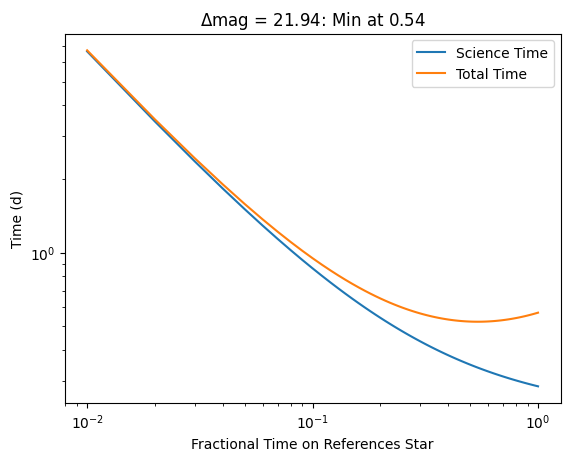

In [46]:
dMag = np.array([21.94]) # Eps Eri. # can be achived at 5 sigma in ~10 hours exposure time


# try range of times on ref star
TK = EXOSIMS.Prototypes.TimeKeeping.TimeKeeping(missionLife = 5.25)
TK.allocate_time(21*30.4375*u.d); # 21 months",
ref_fracs = np.linspace(0.01, 1, 100)
intTimes = np.zeros(len(ref_fracs))*u.d
for j, ref_frac in enumerate(ref_fracs):
    mode["TimeonRefStar_tRef_per_tTar"] = ref_frac
    mode["RefStar_V_mag"] = 2.53 # alf Cet*
    # mode["RefStar_V_mag"] = 2.65 # alf Col
    # mode["RefStar_V_mag"] = 1.69 # Bet Car
    intTimes[j] = OS.calc_intTime(TL, sInds, fZ, JEZ, dMag, WA, mode, TK=TK)[0]

totTimes = intTimes*(1+ref_fracs)
plt.figure()
plt.loglog(ref_fracs, intTimes, label="Science Time")
plt.loglog(ref_fracs, totTimes, label="Total Time")
plt.xlabel(rf"Fractional Time on References Star")
plt.ylabel(f"Time ({intTimes.unit})")
plt.legend()
plt.title(f"$\Delta$mag = {dMag[0]}: Min at {ref_fracs[np.nanargmin(totTimes)] :.2f}");